# GraphRAG Evaluation

This notebook evaluates the GraphRAG pipeline output across three independent components:
1. **Graph retrieval reliability** — entity-level Precision, Recall, F1
2. **Graph generation quality** — LLM-as-a-Judge (reference-guided, multi-agent)
3. **Evaluation cost** — token usage and USD cost per judge

Only **Cell 1 (Configuration)** needs to be edited. All other cells run automatically.

## ⚙️ Cell 1 — Configuration
> Edit only this cell before running the notebook.

In [2]:
# ══════════════════════════════════════════════════════════════════
#  CONFIGURATION — edit only this section
# ══════════════════════════════════════════════════════════════════

# ── Input files (already generated) ──────────────────────────────
GRAPHRAG_OUTPUT_PATH = r"graphrag\data\output\graphrag_results_20260522_171129.xlsx"  # GraphRAG answers + cited entities
GRAPH_PATH           = "LOTO-RO_grounded_KG.xlsx"            # source KG (sheet "entità": id, title)
JUDGE_RESULTS_PATH   = "Evaluationresults/eval_judge.xlsx"   # ← already-generated LLM-as-a-Judge scores
OUTPUT_DIR           = "Evaluationresults/"                  # where figures are saved

# ── Pricing — USD per 1M tokens (used only for the cost chart) ───
PRICING = {
    "openai": {"i": 2.50,  "o": 10.00},   # gpt-5.4
    "gemini": {"i": 0.075, "o": 0.30},    # gemini-3.5-flash
}

print("Configuration loaded")
print("  GraphRAG output :", GRAPHRAG_OUTPUT_PATH)
print("  KG source       :", GRAPH_PATH)
print("  Judge results   :", JUDGE_RESULTS_PATH)
print("  Output dir      :", OUTPUT_DIR)


Configuration loaded
  GraphRAG output : graphrag\data\output\graphrag_results_20260522_171129.xlsx
  KG source       : LOTO-RO_grounded_KG.xlsx
  Judge results   : Evaluationresults/eval_judge.xlsx
  Output dir      : Evaluationresults/


---
## 📐 Section 2 — Graph Retrieval Reliability: Precision, Recall, F1

Entity-level set-based matching between retrieved entity titles (`Cited_Entities_IDs` → resolved to titles) and expert-annotated gold reference (`Gold_Entity_Titles`).

| Metric | Definition |
|--------|------------|
| **Precision** | Of all retrieved entities, what fraction is relevant? |
| **Recall** | Of all relevant entities, what fraction was retrieved? |
| **F1** | Harmonic mean of Precision and Recall |

Entity IDs are resolved to human-readable titles via the KG source file before comparison. Titles are lowercased for case-insensitive matching.

Style applied (black text, font 10). Constants ready.
Loaded 180 GraphRAG rows. Categories: ['Classification', 'Comparison', 'Information Retrieval', 'Reasoning', 'Recommendation', 'Summarization']
Global  —  Precision 0.63  Recall 0.44  F1 0.45


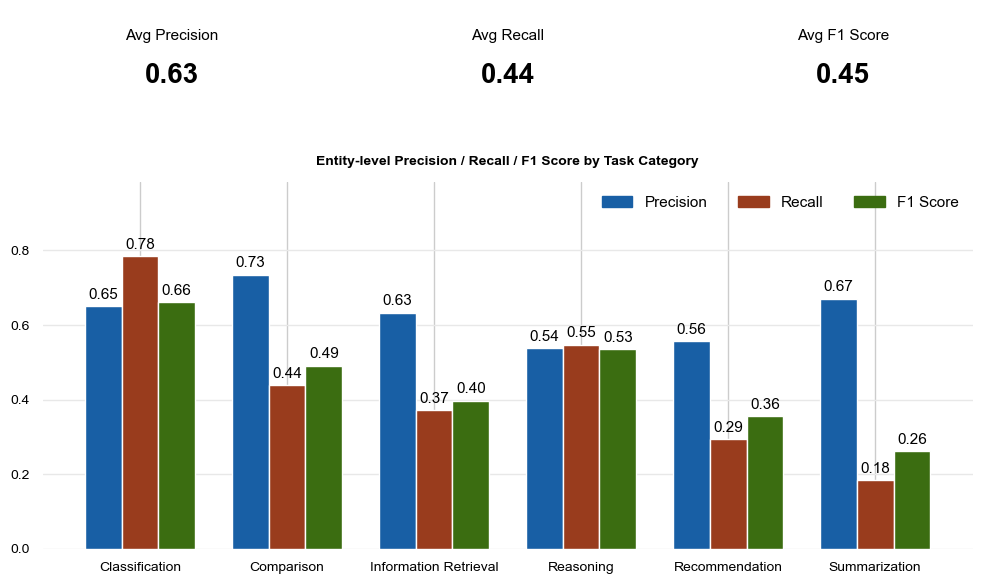

In [7]:
# ── Imports, global style (black text, font 10), label constants ─────────────
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Global style: every text element black, base size 10
mpl.rcParams.update({
    "font.size":        10,
    "axes.titlesize":   10,
    "axes.labelsize":   10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
    "figure.titlesize": 10,
    "axes.titleweight": "bold",
    "text.color":       "black",
    "axes.labelcolor":  "black",
    "axes.titlecolor":  "black",
    "xtick.color":      "black",
    "ytick.color":      "black",
})

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Judge criteria (must match the columns in JUDGE_RESULTS_PATH)
SCORE_FIELDS = [
    "faithfulness_to_source",
    "factual_accuracy",
    "completeness",
    "relevance_and_conciseness",
    "overall_coherence",
    "empowerment",
]
LABELS = ["Faithfulness", "Accuracy", "Comprehensiveness", "Answer Relevance", "Coherence", "Empowerment"]
SC     = [f"s_{f}" for f in SCORE_FIELDS]
JUDGE_LABELS = {"openai": "GPT", "gemini": "Gemini"}
palette      = {"openai": "#f28e2b", "gemini": "#76b7b2"}

print("Style applied (black text, font 10). Constants ready.")
# ── 2.1 Metric functions ─────────────────────────────────────────────────────
def parse_set(cell) -> set:
    s = str(cell).strip() if cell is not None else ""
    if s.lower() in ("", "nan", "none", "all incidents"):
        return set()
    return {x.strip().lower() for x in s.split(",") if x.strip()}


def prf(retrieved: set, relevant: set) -> tuple:
    if not retrieved and not relevant:
        return 1.0, 1.0, 1.0
    if not retrieved:
        return 0.0, 0.0, 0.0
    if not relevant:
        return 0.0, 1.0, 0.0
    tp = len(retrieved & relevant)
    p  = tp / len(retrieved)
    r  = tp / len(relevant)
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    return round(p, 4), round(r, 4), round(f1, 4)


def evaluate_row(row) -> pd.Series:
    retrieved = parse_set(row["Extracted_Entity_Titles"])
    relevant  = parse_set(row["Gold_Entity_Titles"])
    p, r, f1  = prf(retrieved, relevant)
    return pd.Series({"Precision": p, "Recall": r, "F1": f1,
                      "TP": len(retrieved & relevant),
                      "FP": len(retrieved - relevant),
                      "FN": len(relevant  - retrieved)})


# ── 2.2 Load GraphRAG output and resolve entity IDs to titles ────────────────
df_pr  = pd.read_excel(GRAPHRAG_OUTPUT_PATH)
df_ent = pd.read_excel(GRAPH_PATH, sheet_name="Entities")
id_to_title = {str(k).strip(): str(v) for k, v in zip(df_ent["id"], df_ent["title"])
               if pd.notna(k) and pd.notna(v)}


def ids_to_titles(cell) -> str:
    s = str(cell).strip() if cell is not None else ""
    if s.lower() in ("", "nan", "none"):
        return ""
    return ", ".join(id_to_title.get(r.strip(), f"[UNKNOWN:{r.strip()}]")
                     for r in s.split(","))


df_pr["Extracted_Entity_Titles"] = df_pr["Cited_Entities_IDs"].apply(ids_to_titles)
print(f"Loaded {len(df_pr)} GraphRAG rows. Categories: {df_pr['Category'].unique().tolist()}")

# ── 2.3 Compute metrics and aggregate ────────────────────────────────────────
metrics = df_pr.apply(evaluate_row, axis=1)
detail  = pd.concat([df_pr[["Task_ID", "Variant", "Category", "Search_Type"]].reset_index(drop=True),
                     metrics.reset_index(drop=True)], axis=1)

AGG = {"P_mean": ("Precision", "mean"), "R_mean": ("Recall", "mean"),
       "F1_mean": ("F1", "mean"), "N": ("F1", "count")}
summary_df = detail.groupby(["Search_Type", "Category"], as_index=False).agg(**AGG).round(4)

avg_p, avg_r, avg_f1 = detail["Precision"].mean(), detail["Recall"].mean(), detail["F1"].mean()
print(f"Global  —  Precision {avg_p:.2f}  Recall {avg_r:.2f}  F1 {avg_f1:.2f}")

# ── 2.4 Retrieval chart: Precision / Recall / F1 by task category ────────────
categories = summary_df["Category"]
x     = np.arange(len(categories))
width = 0.25

fig = plt.figure(figsize=(12, 7), facecolor="white")
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 4], hspace=0.35, wspace=0.3)

# KPI cards (average numbers larger for legibility, all black)
for ax_c, label, value in [
    (fig.add_subplot(gs[0, 0]), "Avg Precision", avg_p),
    (fig.add_subplot(gs[0, 1]), "Avg Recall",    avg_r),
    (fig.add_subplot(gs[0, 2]), "Avg F1 Score",  avg_f1),
]:
    ax_c.set_facecolor("#f5f5f5"); ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1); ax_c.axis("off")
    ax_c.text(0.5, 0.72, label, ha="center", va="center", fontsize=11, color="black",
              transform=ax_c.transAxes)
    ax_c.text(0.5, 0.28, f"{value:.2f}", ha="center", va="center", fontsize=20,
              fontweight="bold", color="black", transform=ax_c.transAxes)

ax = fig.add_subplot(gs[1, :])
ax.set_facecolor("white")
b1 = ax.bar(x - width, summary_df["P_mean"],  width, color="#185FA5", label="Precision", zorder=3)
b2 = ax.bar(x,         summary_df["R_mean"],  width, color="#993C1D", label="Recall",    zorder=3)
b3 = ax.bar(x + width, summary_df["F1_mean"], width, color="#3B6D11", label="F1 Score",  zorder=3)
for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012, f"{h:.2f}",
                ha="center", va="bottom", fontsize=11, color="black")

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10, color="black")
ax.set_ylim(0, float(summary_df[["P_mean", "R_mean", "F1_mean"]].max().max()) + 0.20)
ax.yaxis.grid(True, color="#e8e8e8", zorder=0); ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.legend(handles=[mpatches.Patch(color="#185FA5", label="Precision"),
                   mpatches.Patch(color="#993C1D", label="Recall"),
                   mpatches.Patch(color="#3B6D11", label="F1 Score")],
          frameon=False, fontsize=11, loc="upper right", ncol=3)
ax.set_title("Entity-level Precision / Recall / F1 Score by Task Category",
             fontweight="bold", pad=12)

plt.savefig(f"{OUTPUT_DIR}retrieval_chart.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

---
## 🤖 Section 3 — Graph Generation Quality: LLM-as-a-Judge

Reference-guided grading on a 1–5 Likert scale across six evaluation criteria, using a multi-agent strategy (two independent judges from distinct provider families) to mitigate single-judge variance.

| Criterion | What it measures |
|-----------|------------------|
| **Faithfulness** | Every claim grounded in the retrieved subgraph — penalises hallucinations |
| **Accuracy** | Factual alignment with the expert-validated gold answer |
| **Comprehensiveness** | Coverage of required procedural, causal, and relational aspects |
| **Relevance & Conciseness** | Answer focused on the query without off-topic padding |
| **Clarity & Readability** | Logical structure and readability |
| **Overall Coherence** | Internal consistency, free of contradictions |
| **Empowerment** | Decision-support utility for a safety professional |

> **Context Confidence** is evaluated independently to distinguish retrieval failures from generation failures.

A response is considered **acceptable** at score ≥ 4.

In [8]:
# ── 3.1 Load already-generated judge scores ──────────────────────────────────
JUDGE_RESULTS_PATH = r"Evaluationresults\eval_judge_20260522_221944.xlsx"

all_res = pd.read_excel(JUDGE_RESULTS_PATH)

# Ensure score columns are numeric
present_sc = [c for c in SC if c in all_res.columns]
for c in present_sc:
    all_res[c] = pd.to_numeric(all_res[c], errors="coerce")

valid_res = all_res.dropna(subset=present_sc)
print(f"Loaded {len(all_res)} judge records  ({valid_res['judge'].value_counts().to_dict()} valid by judge)")

Loaded 360 judge records  ({'openai': 180, 'gemini': 180} valid by judge)


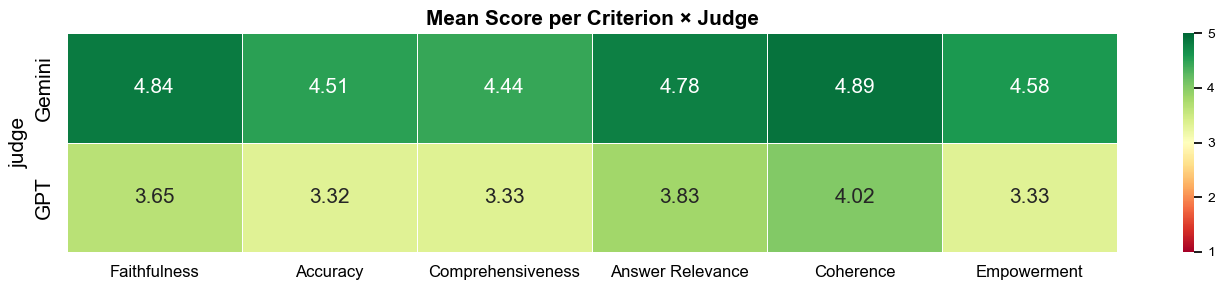

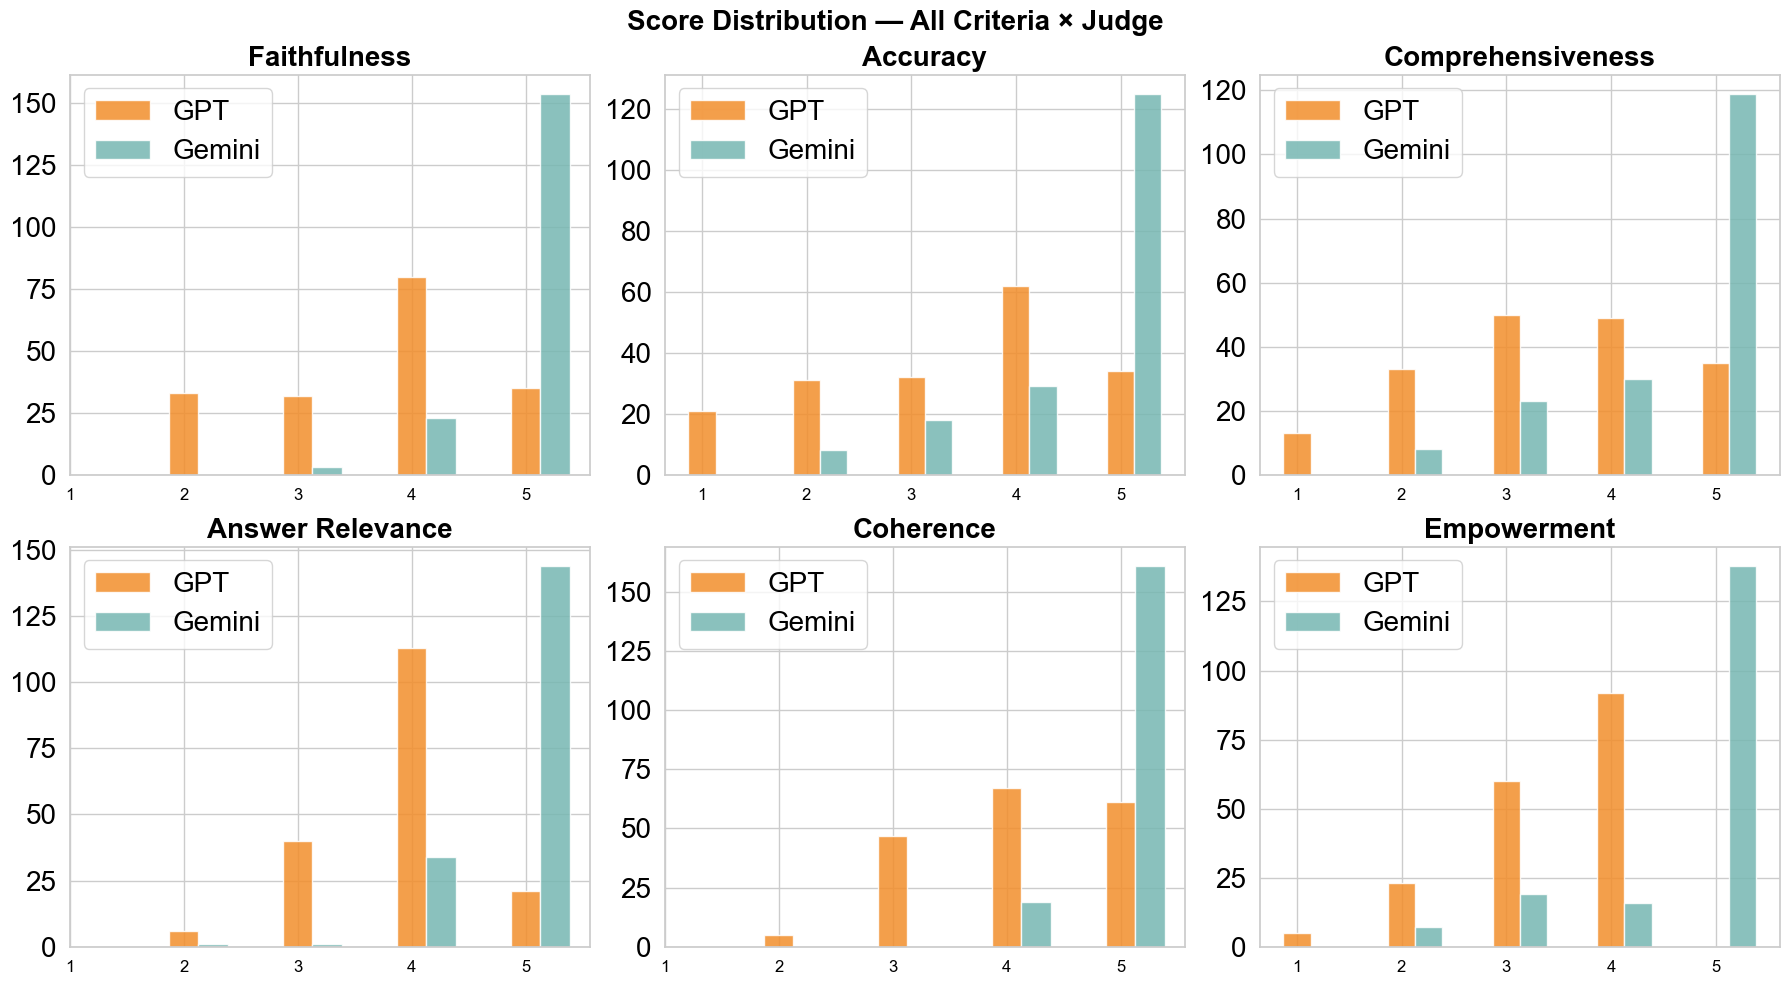

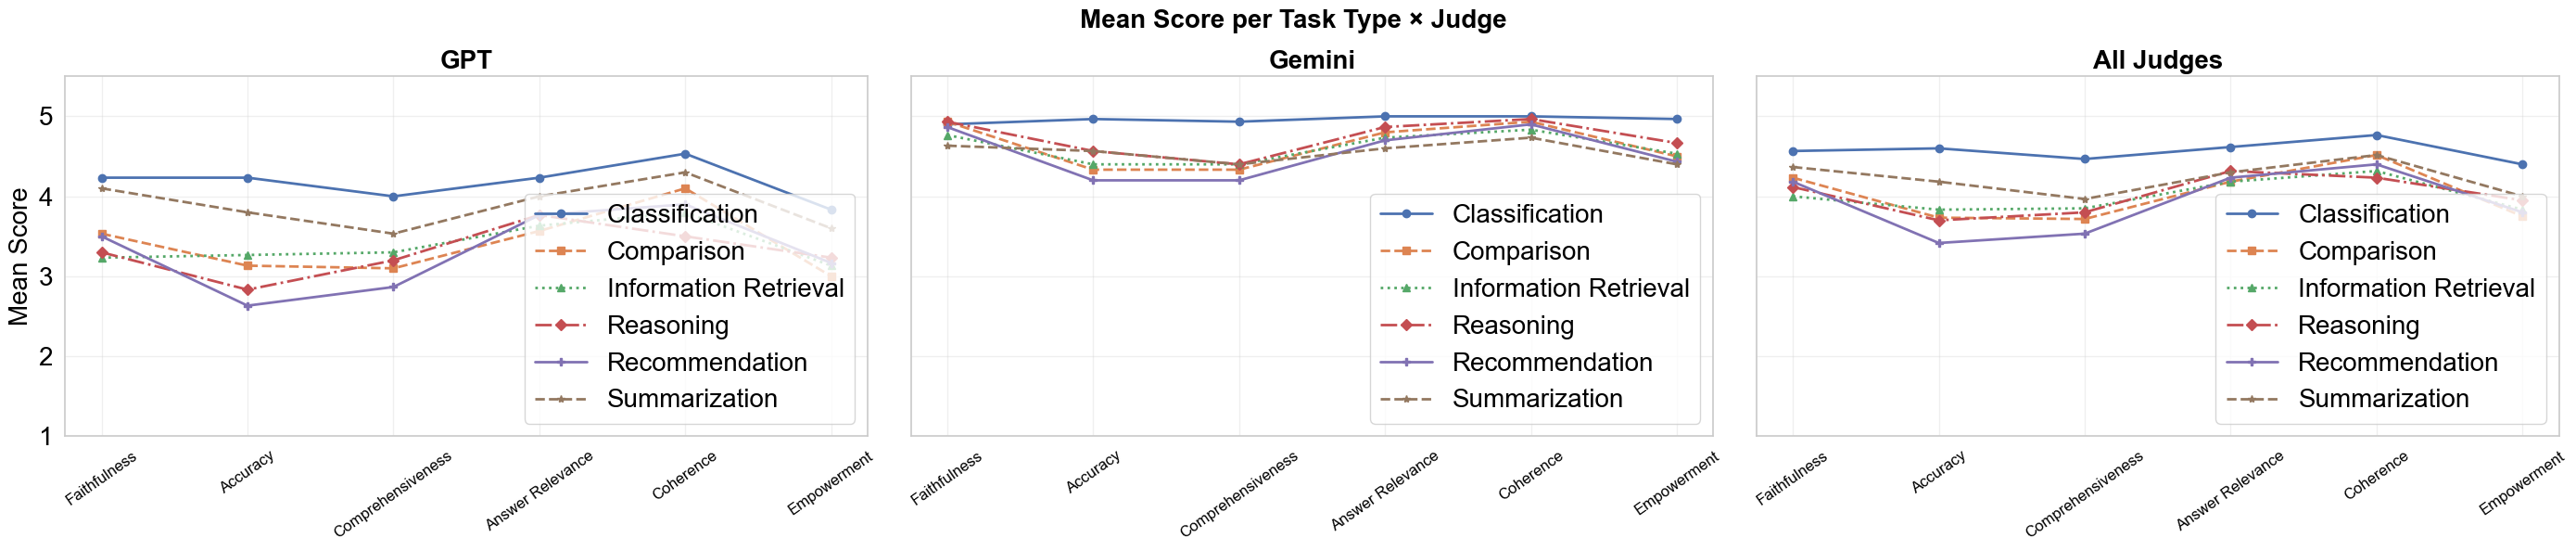

In [9]:
# ── 3.2 Heatmap, score distribution, per-task-type profiles ──────────────────
FS_HEATMAP  = 15   # heatmap text
FS          = 20   # everything else in this cell
FS_XLABELS  = 12   # x-axis tick labels (criteri) — più piccolo del resto

# Heatmap — mean score per criterion × judge
pv = valid_res.groupby("judge")[SC].mean()
pv.columns = LABELS
pv.index   = pv.index.map(JUDGE_LABELS)

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5,
            linewidths=.5, ax=ax, annot_kws={"size": FS_HEATMAP})
ax.set_title("Mean Score per Criterion × Judge", fontweight="bold", fontsize=FS_HEATMAP)
ax.set_ylabel("judge", fontsize=FS_HEATMAP)
ax.tick_params(axis="y", labelsize=FS_HEATMAP)
ax.tick_params(axis="x", labelsize=FS_XLABELS)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}heatmap_mean.png", dpi=150)
plt.show()

# Distribution — all criteria
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
w = 0.26
offsets = {"openai": 0, "gemini": w}
for i, (col, lab) in enumerate(zip(SC, LABELS)):
    ax = axes[i // 3, i % 3]
    for jk, jl in JUDGE_LABELS.items():
        v = valid_res[valid_res["judge"] == jk][col].value_counts().sort_index()
        ax.bar(v.index + offsets[jk], v.values, width=w, label=jl, alpha=0.85, color=palette[jk])
    ax.set_title(lab, fontweight="bold", fontsize=FS)
    ax.set_xticks(range(1, 6))
    ax.tick_params(axis="x", labelsize=FS_XLABELS)
    ax.tick_params(axis="y", labelsize=FS)
    ax.legend(fontsize=FS)
plt.suptitle("Score Distribution — All Criteria × Judge", fontweight="bold", fontsize=FS)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}distribution.png", dpi=150)
plt.show()

# Per task type
task_types = sorted(valid_res["Category"].unique())
judges_ext = list(JUDGE_LABELS.items()) + [("all", "All Judges")]
fig, axes = plt.subplots(1, 3, figsize=(28, 6), sharey=True)
ls_map = dict(zip(task_types, ["o-", "s--", "^:", "D-.", "P-", "*--"]))
for ax_i, (jk, jl) in enumerate(judges_ext):
    ax  = axes[ax_i]
    sub = valid_res if jk == "all" else valid_res[valid_res["judge"] == jk]
    for tt in task_types:
        tt_sub = sub[sub["Category"] == tt]
        if len(tt_sub) == 0:
            continue
        means = [tt_sub[col].mean() for col in SC]
        ax.plot(LABELS, means, ls_map.get(tt, "o-"), label=tt, linewidth=2, markersize=6)
    ax.set_title(jl, fontweight="bold", fontsize=FS)
    ax.set_ylim(1, 5.5); ax.tick_params(axis="x", rotation=35); ax.grid(alpha=.3)
    ax.tick_params(axis="x", labelsize=FS_XLABELS)
    ax.tick_params(axis="y", labelsize=FS)
    if ax_i == 0:
        ax.set_ylabel("Mean Score", fontsize=FS)
    ax.legend(loc="lower right", fontsize=FS)
plt.suptitle("Mean Score per Task Type × Judge", fontweight="bold", fontsize=FS)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}by_tasktype_line.png", dpi=150)
plt.show()

Inter-judge agreement GPT vs Gemini  (n = 180 paired items)
                       rs  pct_within1
Faithfulness       0.0602         68.3
Accuracy           0.6740         64.4
Comprehensiveness  0.7287         65.6
Answer Relevance   0.2248         82.2
Coherence         -0.0076         74.4
Empowerment        0.4886         66.1

Mean Spearman rho across criteria: 0.36


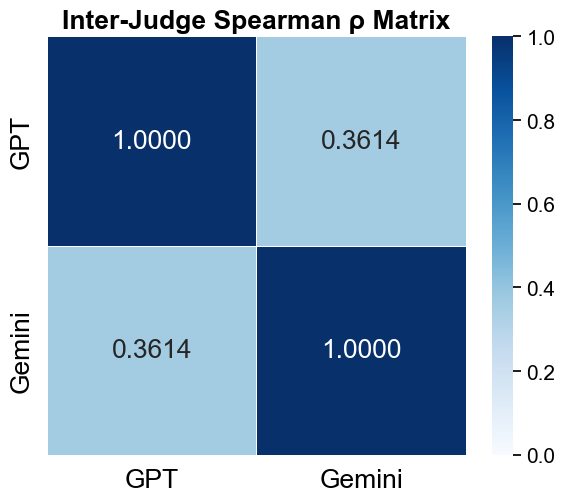

In [10]:
# ── 3.3 Inter-judge agreement (Spearman ρ) ───────────────────────────────────
def norm_tid(x):
    try:
        f = float(x)
        return str(int(f)) if f == int(f) else str(f)
    except Exception:
        return str(x)


def spearman_pair(df_all, j1, j2):
    def idx_set(j):
        sub = df_all[df_all["judge"] == j].copy()
        sub["key"] = sub["Task_ID"].apply(norm_tid).astype(str) + "_" + sub["Variant"].astype(str)
        return sub.set_index("key")
    a, b   = idx_set(j1), idx_set(j2)
    common = a.index.intersection(b.index)
    result = {}
    for col, lab in zip(SC, LABELS):
        if len(common) < 3:
            result[lab] = {"rs": float("nan"), "pct_within1": float("nan")}
        else:
            x, y   = a.loc[common, col], b.loc[common, col]
            rs, _  = stats.spearmanr(x, y)
            result[lab] = {"rs": round(rs, 4), "pct_within1": round((abs(x - y) <= 1).mean() * 100, 1)}
    return pd.DataFrame(result).T, len(common)


agdf, n = spearman_pair(valid_res, "openai", "gemini")
print(f"Inter-judge agreement GPT vs Gemini  (n = {n} paired items)")
print(agdf.to_string())
print(f"\nMean Spearman rho across criteria: {agdf['rs'].mean():.2f}")

# ── Chart: Inter-Judge Spearman ρ matrix (GPT vs Gemini) ─────────────────────
FS    = 19   # title, axis labels, in-cell annotations
FS_CB = 15   # colorbar tick numbers

rho = agdf["rs"].mean()   # overall inter-judge correlation (mean across criteria)

rs_matrix = pd.DataFrame(
    [[1.0, rho], [rho, 1.0]],
    index=["GPT", "Gemini"], columns=["GPT", "Gemini"],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(rs_matrix, annot=True, fmt=".4f", cmap="Blues", vmin=0, vmax=1,
            square=True, linewidths=.5, cbar=True, ax=ax, annot_kws={"size": FS})
ax.set_title("Inter-Judge Spearman ρ Matrix", fontweight="bold", fontsize=FS)
ax.tick_params(labelsize=FS)

# Enlarge the colorbar tick numbers
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=FS_CB)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}interjudge_spearman_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

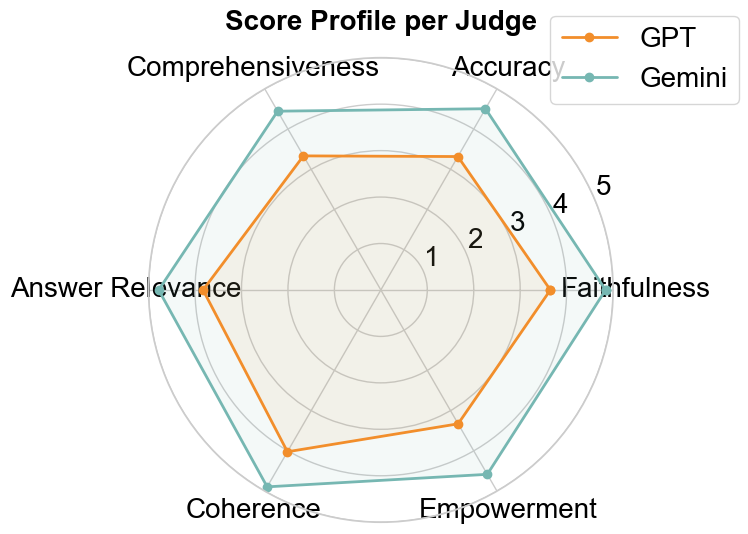

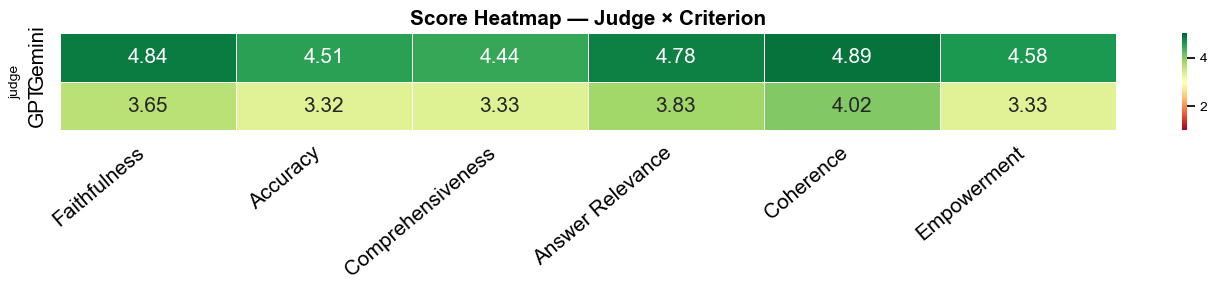

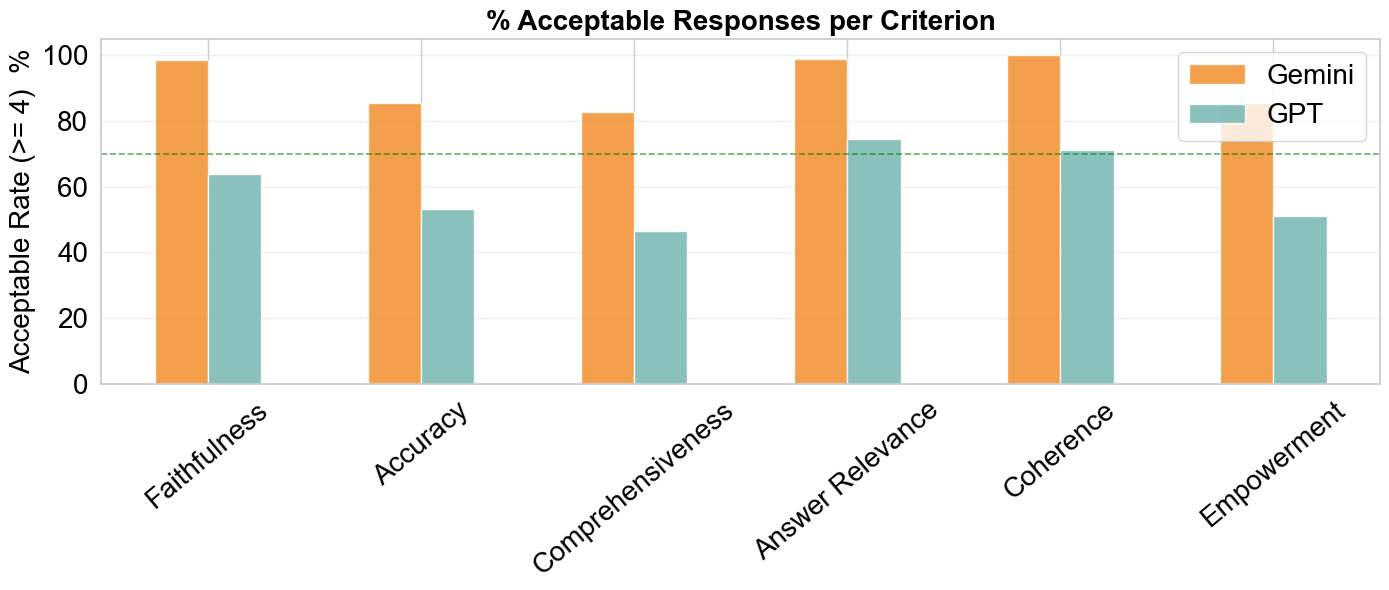

In [11]:
# ── 3.4 Summary figures (three separate charts) ──────────────────────────────
FS         = 20   # radar and acceptable-rate
FS_HEATMAP = 15   # heatmap

# ── Chart 1: Radar — score profile per judge ─────────────────────────────────
fig = plt.figure(figsize=(8, 8))
ax_r = fig.add_subplot(1, 1, 1, polar=True)
angles = np.linspace(0, 2 * np.pi, len(LABELS), endpoint=False).tolist()
angles += angles[:1]
for jkey, jlabel in [("openai", "GPT"), ("gemini", "Gemini")]:
    sub    = valid_res[valid_res["judge"] == jkey]
    values = [sub[c].mean() for c in SC] if len(sub) else [0] * len(SC)
    values += values[:1]
    ax_r.plot(angles, values, "o-", linewidth=2, label=jlabel, color=palette[jkey])
    ax_r.fill(angles, values, alpha=0.08, color=palette[jkey])
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(LABELS, fontsize=FS)
ax_r.set_ylim(0, 5); ax_r.set_yticks([1, 2, 3, 4, 5]); ax_r.tick_params(labelsize=FS)
ax_r.set_title("Score Profile per Judge", fontweight="bold", fontsize=FS, pad=20)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.30, 1.12), fontsize=FS)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}summary_radar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 2: Heatmap — judge × criterion ─────────────────────────────────────
fig, ax_h = plt.subplots(figsize=(14, 3))
pv_all = valid_res.groupby("judge")[SC].mean()
pv_all.columns = LABELS; pv_all.index = pv_all.index.map(JUDGE_LABELS)
sns.heatmap(pv_all, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5,
            linewidths=.5, ax=ax_h, annot_kws={"size": FS_HEATMAP})
ax_h.set_title("Score Heatmap — Judge × Criterion", fontweight="bold", fontsize=FS_HEATMAP)
ax_h.set_xticklabels(LABELS, rotation=40, ha="right", fontsize=FS_HEATMAP)
ax_h.tick_params(axis="y", labelsize=FS_HEATMAP)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}summary_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Chart 3: Acceptable rate (>= 4) per criterion ────────────────────────────
fig, ax_a = plt.subplots(figsize=(14, 6))
sar_cols  = [f"sar_{f}" for f in SCORE_FIELDS]
sar_means = valid_res.groupby("judge")[sar_cols].mean() * 100
sar_means.columns = LABELS; sar_means.index = sar_means.index.map(JUDGE_LABELS)
sar_means.T.plot(kind="bar", ax=ax_a, color=[palette["openai"], palette["gemini"]], alpha=0.85)
ax_a.set_ylabel("Acceptable Rate (>= 4)  %", fontsize=FS); ax_a.set_ylim(0, 105)
ax_a.set_title("% Acceptable Responses per Criterion", fontweight="bold", fontsize=FS)
ax_a.tick_params(axis="x", rotation=40, labelsize=FS); ax_a.tick_params(axis="y", labelsize=FS)
ax_a.legend(fontsize=FS)
ax_a.axhline(70, color="green", lw=1.2, ls="--", alpha=0.6)
ax_a.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}summary_acceptable_rate.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 💰 Section 4 — Evaluation Cost

Actual token usage and USD cost for the LLM-as-a-Judge evaluation run, computed from real usage metadata reported by each API. Prices are read from the `PRICING` dict defined in Cell 1 — update if rates change.

  EVALUATION COST — LLM-as-a-Judge
          n  tok_in  tok_out  avg_s     usd
judge                                      
Gemini  180  865605    86350    3.1  0.0908
GPT     180  807000    93994    8.4  2.9574

Total estimated cost: $3.0482
Avg cost per query  : $0.00847



NameError: name 'config' is not defined

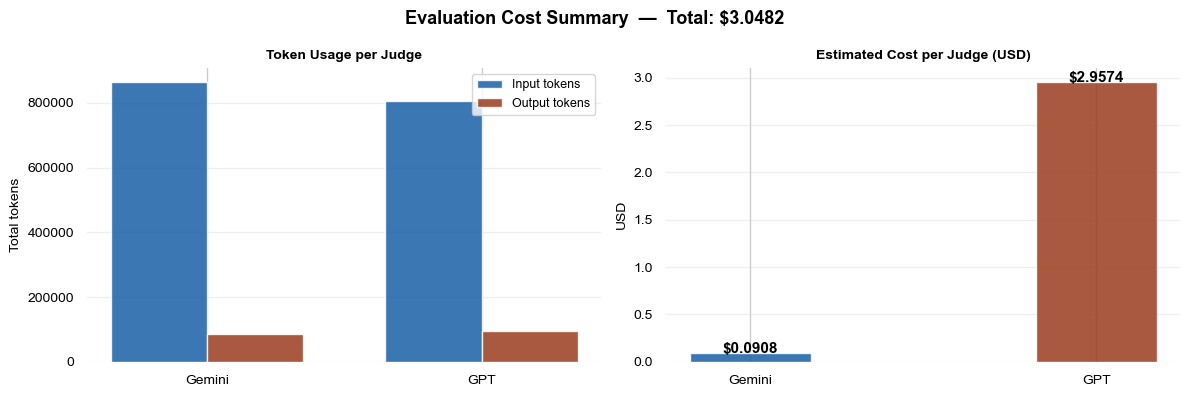

In [14]:
# ── 4.1 Cost computation from actual token usage ─────────────────────────────

u = all_res.groupby("judge").agg(
    n       = ("Task_ID", "count"),
    tok_in  = ("tok_in",  "sum"),
    tok_out = ("tok_out", "sum"),
    avg_s   = ("time_s",  "mean"),
).round(1)

for j in u.index:
    p = PRICING.get(j, {"i": 0, "o": 0})
    u.loc[j, "usd"] = round(
        u.loc[j, "tok_in"]  / 1e6 * p["i"] +
        u.loc[j, "tok_out"] / 1e6 * p["o"], 4
    )

u.index = u.index.map({"openai": "GPT", "gemini": "Gemini"})
print("=" * 55)
print("  EVALUATION COST — LLM-as-a-Judge")
print("=" * 55)
print(u[["n", "tok_in", "tok_out", "avg_s", "usd"]].to_string())
print(f"\nTotal estimated cost: ${u['usd'].sum():.4f}")
print(f"Avg cost per query  : ${u['usd'].sum() / u['n'].sum():.5f}")
print()

# Cost breakdown chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="white")

# Token usage
ax = axes[0]
bar_w = 0.35
x_pos = np.arange(len(u))
ax.bar(x_pos - bar_w/2, u["tok_in"],  bar_w, label="Input tokens",  color="#185FA5", alpha=0.85)
ax.bar(x_pos + bar_w/2, u["tok_out"], bar_w, label="Output tokens", color="#993C1D", alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(u.index)
ax.set_ylabel("Total tokens"); ax.set_title("Token Usage per Judge", fontweight="bold")
ax.legend(fontsize=9); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)

# USD cost
ax2 = axes[1]
colors = ["#185FA5", "#993C1D", "#3B6D11"]
bars = ax2.bar(u.index, u["usd"], color=colors[:len(u)], alpha=0.85, width=0.35)
for bar, val in zip(bars, u["usd"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f"${val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("USD"); ax2.set_title("Estimated Cost per Judge (USD)", fontweight="bold")
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)
for spine in ax2.spines.values(): spine.set_visible(False)

plt.suptitle(f"Evaluation Cost Summary  —  Total: ${u['usd'].sum():.4f}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{config.output_dir}eval_cost.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Cost chart saved: {config.output_dir}eval_cost.png ✓")
print()
print("Note: Prices are read from the PRICING dict in Cell 1.")
print("Update them at https://openai.com/pricing and https://ai.google.dev/pricing")
